## Business Objective
The objective of this project is to develop a deep learning-based model for automatic facial expression recognition using images containing labeled emotions such as fear, anger, happiness, and disgust.

## Importing data and setup the enviroment

In [ ]:
# Connecting my google drive with my collab file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create a directory for the Kaggle API key
!mkdir -p ~/.kaggle

# Copy and rename the file to kaggle.json
!cp /content/drive/MyDrive/ANNCNNRNN/CNN/kaggle_api_key.json ~/.kaggle/kaggle.json

# Set the permissions
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Downloading the dataset from the Kaggle
!kaggle datasets download -d jonathanoheix/face-expression-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset
License(s): unknown


In [ ]:
!unzip /content/face-expression-recognition-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/validation/fear/8797.jpg  
  inflating: images/validation/fear/8818.jpg  
  inflating: images/validation/fear/886.jpg  
  inflating: images/validation/fear/9037.jpg  
  inflating: images/validation/fear/9040.jpg  
  inflating: images/validation/fear/9101.jpg  
  inflating: images/validation/fear/911.jpg  
  inflating: images/validation/fear/9179.jpg  
  inflating: images/validation/fear/9205.jpg  
  inflating: images/validation/fear/9232.jpg  
  inflating: images/validation/fear/9251.jpg  
  inflating: images/validation/fear/9261.jpg  
  inflating: images/validation/fear/9281.jpg  
  inflating: images/validation/fear/9302.jpg  
  inflating: images/validation/fear/9333.jpg  
  inflating: images/validation/fear/9369.jpg  
  inflating: images/validation/fear/9370.jpg  
  inflating: images/validation/fear/9474.jpg  
  inflating: images/validation/fear/949.jpg  
  inflating: images/validation/fear/9602.jpg  
  inflating:

In [ ]:
# Importing Libraries

# Basic import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os

# Keras import
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

#SkLearn
from sklearn.metrics import classification_report, confusion_matrix

## Pre-processing

In [ ]:
# Importing my train data and validataion data
# Creating a dataset from my images

train_data = keras.utils.image_dataset_from_directory(
    directory = '/content/images/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256),
    color_mode='grayscale',
    seed = 123,
    validation_split= None      # As I have separate folders for both training and validation
)

val_data = keras.utils.image_dataset_from_directory(
    directory = '/content/images/validation',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256),
    color_mode='grayscale',
    seed = 123,
    validation_split= None
)

Found 28821 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.


In [ ]:
train_data

# My train data will be a batch of images (shape: (32, 256, 256, 1) as my batch_size is 32 and labels will be the corresponding batch of labels shape: (32,)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
# Converting TensorSpec to Numpy array to see what data looks like and to visualize the data
for images, labels in train_data.take(1):
  img_array = np.array(images[4])
  print(img_array)
  print("The size of my image is:",img_array.shape)

[[[255.]
  [255.]
  [255.]
  ...
  [ 72.]
  [ 72.]
  [ 72.]]

 [[255.]
  [255.]
  [255.]
  ...
  [ 72.]
  [ 72.]
  [ 72.]]

 [[255.]
  [255.]
  [255.]
  ...
  [ 72.]
  [ 72.]
  [ 72.]]

 ...

 [[ 13.]
  [ 13.]
  [ 13.]
  ...
  [  6.]
  [  6.]
  [  6.]]

 [[ 13.]
  [ 13.]
  [ 13.]
  ...
  [  6.]
  [  6.]
  [  6.]]

 [[ 13.]
  [ 13.]
  [ 13.]
  ...
  [  6.]
  [  6.]
  [  6.]]]
The size of my image is: (256, 256, 1)


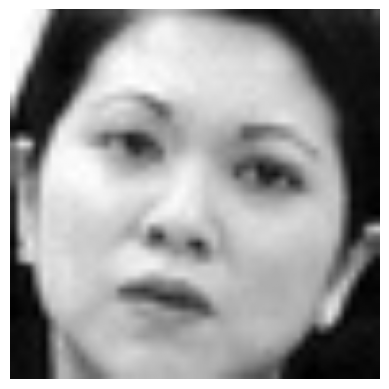

In [ ]:
plt.imshow(img_array, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# Normalizing my train and validation data to avoid overfitting

# Function to normalize image
def normalize(images, labels):
  images = images/255.0
  return images, labels

# Apply normalization to train and validation datasets
train_data = train_data.map(normalize)
val_data = val_data.map(normalize)

In [ ]:
# How my data look like after aplying normalization. Its in the range between 0 and 1.
for images, labels in train_data.take(1):
  image_arrays = np.array(images[0])
  print(image_arrays)
  print(image_arrays.shape)

[[[0.6313726 ]
  [0.6313726 ]
  [0.6313726 ]
  ...
  [0.16862746]
  [0.16862746]
  [0.16862746]]

 [[0.6313726 ]
  [0.6313726 ]
  [0.6313726 ]
  ...
  [0.16862746]
  [0.16862746]
  [0.16862746]]

 [[0.6313726 ]
  [0.6313726 ]
  [0.6313726 ]
  ...
  [0.16862746]
  [0.16862746]
  [0.16862746]]

 ...

 [[0.25882354]
  [0.25882354]
  [0.25882354]
  ...
  [0.32941177]
  [0.32941177]
  [0.32941177]]

 [[0.25882354]
  [0.25882354]
  [0.25882354]
  ...
  [0.32941177]
  [0.32941177]
  [0.32941177]]

 [[0.25882354]
  [0.25882354]
  [0.25882354]
  ...
  [0.32941177]
  [0.32941177]
  [0.32941177]]]
(256, 256, 1)


## Model implication

In [ ]:
model = Sequential()

model.add(Conv2D(16, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape = (256,256,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'valid'))

model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(7, activation='softmax'))         # I have put 7 nodes on the output layer because we are dealing with class classification which have 7 categories

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,318,215 (12.66 MB)

 Trainable params: 3,317,735 (12.66 MB)

 Non-trainable params: 480 (1.88 KB)

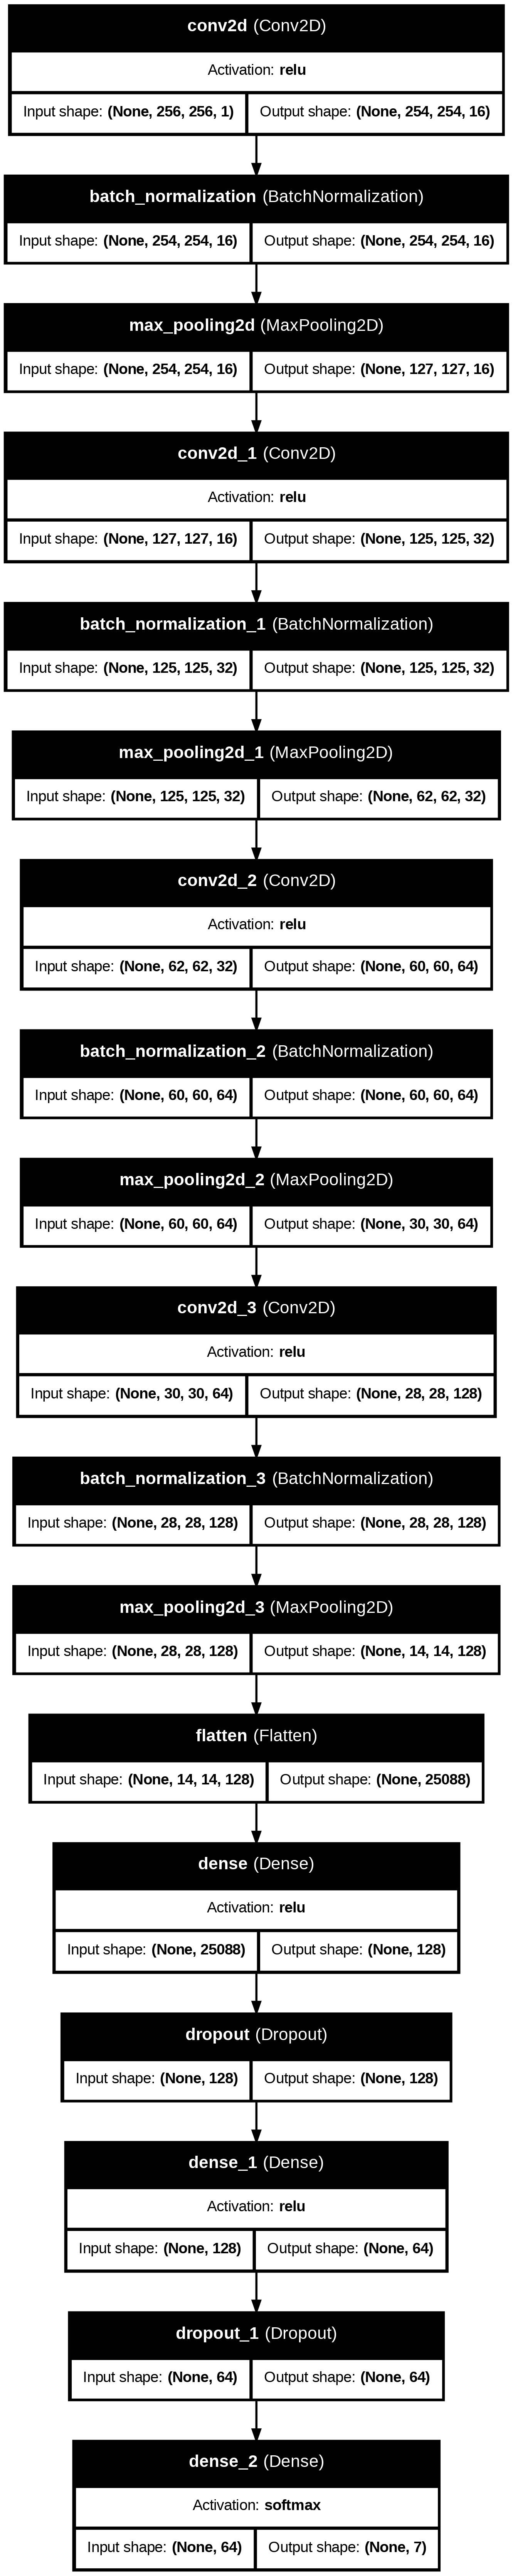

In [ ]:
from tensorflow.keras.utils import plot_model

# Plotting the model architecture
plot_model(model,
           to_file='model_plot.png',   # saves it to a file
           show_shapes=True,           # shows the shape of output at each layer
           show_layer_names=True,      # shows the layer names
           show_layer_activations=True)

In [ ]:
model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=20, validation_data=val_data)

Epoch 1/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 52s 45ms/step - accuracy: 0.2581 - loss: 2.1812 - val_accuracy: 0.3801 - val_loss: 1.5767
Epoch 2/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.4019 - loss: 1.5270 - val_accuracy: 0.2942 - val_loss: 1.7277
Epoch 3/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.4681 - loss: 1.3829 - val_accuracy: 0.4615 - val_loss: 1.4164
Epoch 4/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.5128 - loss: 1.2789 - val_accuracy: 0.4789 - val_loss: 1.3659
Epoch 5/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.5564 - loss: 1.1621 - val_accuracy: 0.5262 - val_loss: 1.2677
Epoch 6/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.6033 - loss: 1.0516 - val_accuracy: 0.5127 - val_loss: 1.3356
Epoch 7/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.6528 - loss: 0.9383 - val_accuracy: 0.5293 - val_loss: 1.3401
Epoch 8/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.6997 - loss: 0.8204 - 

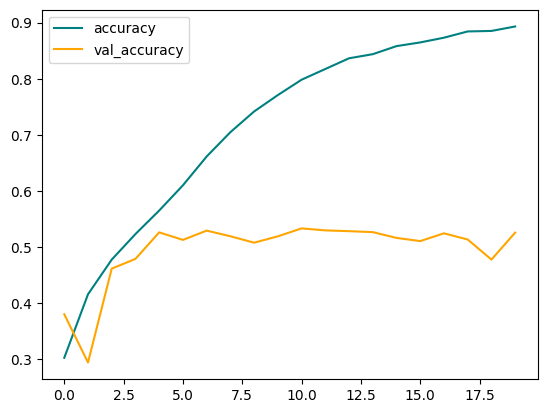

In [ ]:
# Plot graph between accuracy and validation accuracy

plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
plt.legend()
plt.show()

## Testing

In [ ]:
import cv2

In [ ]:
# Load as grayscale
test_image = cv2.imread('/content/10001.jpg', cv2.IMREAD_GRAYSCALE)

In [ ]:
test_image.shape

(48, 48)

In [ ]:
# Resize
test_image = cv2.resize(test_image, (256, 256))

In [ ]:
# Expand channel
test_image = np.expand_dims(test_image, axis=-1)  # (256, 256, 1)

In [ ]:
# Normalize
test_image = test_image / 255.0

In [ ]:
# Expand batch dimension
test_image = np.expand_dims(test_image, axis=0)  # (1, 256, 256, 1)

In [ ]:
# Now predict
prediction = model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [ ]:
prediction

array([[3.38772172e-03, 1.03941944e-04, 2.93145962e-02, 8.39410126e-01,
        9.87773383e-05, 1.93542408e-04, 1.27491280e-01]], dtype=float32)

In [ ]:
# Assume you already have class names saved
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']  # Order in which my folder is present

# Find the index of the highest value
predicted_index = np.argmax(prediction)

# Get the class label
predicted_class = class_names[predicted_index]

print(f"Predicted Class: {predicted_class}")

Predicted Class: happy
